# Stage 3 Global LSTM Encoder, Version 3.1, Post-Run Validation Notebook

Goal: After V3.1 training completes, verify the run is scientifically valid and technically correct.

This notebook checks:
1. Data integrity: required columns, NaNs, per-plant coverage, time ranges.
2. Leakage: train/val overlap, fold boundary correctness, window integrity (no cross-plant windows, no cadence jumps).
3. Training behavior: underfit/overfit signals via loss curves and train/val ratios.
4. Practical sanity: baseline RMSE (persistence) and daytime-only metrics to avoid night-dominated illusions.
5. Transfer learning evidence: compare Farm2107 weights vs trained fold weights, confirm plant one-hot weights learned.
6. Comparison vs Version 2: show metrics side-by-side with caveats (different split regimes).


In [2]:
import os
from pathlib import Path
import math
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

#set pwd to project root
if Path.cwd().name == "lstm":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

# Repo and run paths
REPO_ROOT = Path.home() / "pv_forecast_30d"
DATA_DIR = REPO_ROOT / "data" / "processed" / "pretraining" / "germany" / "global"
RUNS_DIR = REPO_ROOT / "experiments" / "lstm" / "runs" / "germany" / "global_v3"
FARM2107_CKPT = REPO_ROOT / "experiments" / "lstm" / "encoders" / "lstm_encoder_farm2107_CANONICAL.pt"

# Folds actually generated right now
FOLDS = [1, 2, 3, 4]

# Fold labels (keep simple and honest)
FOLD_MAP = {
    1: {"season": "Spring", "role": "CV"},
    2: {"season": "Summer", "role": "CV"},
    3: {"season": "Fall",   "role": "CV"},
    4: {"season": "Winter", "role": "CV"},
}

# Columns and schema
from src.data.schema import (
    TIME_COL, PLANT_ID_COL, TARGET_COL,
    LSTM_INPUT_FEATURES, GLOBAL_LSTM_INPUT_FEATURES, PLANT_ONEHOT_COLS,
    TIME_STEP_MINUTES
)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("FARM2107_CKPT exists:", FARM2107_CKPT.exists())
print("len(LSTM_INPUT_FEATURES):", len(LSTM_INPUT_FEATURES))
print("len(PLANT_ONEHOT_COLS):", len(PLANT_ONEHOT_COLS))
print("len(GLOBAL_LSTM_INPUT_FEATURES):", len(GLOBAL_LSTM_INPUT_FEATURES))


REPO_ROOT: /home/dwijenayake/pv_forecast_30d
DATA_DIR: /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global
RUNS_DIR: /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3
FARM2107_CKPT exists: True
len(LSTM_INPUT_FEATURES): 15
len(PLANT_ONEHOT_COLS): 5
len(GLOBAL_LSTM_INPUT_FEATURES): 20


In [3]:
import sys
from pathlib import Path

REPO_ROOT = Path.home() / "pv_forecast_30d"
sys.path.insert(0, str(REPO_ROOT))
print("Injected:", REPO_ROOT)


Injected: /home/dwijenayake/pv_forecast_30d


In [4]:
from src.data.schema import (
    TIME_COL, PLANT_ID_COL, TARGET_COL,
    LSTM_INPUT_FEATURES, GLOBAL_LSTM_INPUT_FEATURES, PLANT_ONEHOT_COLS,
    TIME_STEP_MINUTES
)
print("schema import OK")
print(len(LSTM_INPUT_FEATURES), len(PLANT_ONEHOT_COLS), len(GLOBAL_LSTM_INPUT_FEATURES))


schema import OK
15 5 20


In [5]:
print("kernel ok")

kernel ok


## 1. File existence audit

Checks:
- fold_{k}_train.parquet and fold_{k}_val.parquet exist for all folds
- metrics.csv exists after training
- fold model `.pt` exists after training


In [6]:
def must_exist(p: Path) -> bool:
    ok = p.exists()
    print(("OK  " if ok else "MISS"), str(p))
    return ok

all_ok = True

for k in FOLDS:
    all_ok &= must_exist(DATA_DIR / f"fold_{k}_train.parquet")
    all_ok &= must_exist(DATA_DIR / f"fold_{k}_val.parquet")

for k in FOLDS:
    all_ok &= must_exist(RUNS_DIR / f"fold_{k}" / f"logs" / "metrics.csv")
    all_ok &= must_exist(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt")

print("\nALL FILES OK:", all_ok)


OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_1/logs/metrics.csv
OK   /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_1/lst

## 2. Data integrity checks (per fold)

Checks:
- required columns present
- no NaNs in input features or target
- time ranges per fold
- per-plant row counts per fold


In [7]:
def load_fold(k: int):
    tr = pd.read_parquet(DATA_DIR / f"fold_{k}_train.parquet")
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")
    tr[TIME_COL] = pd.to_datetime(tr[TIME_COL], utc=True)
    va[TIME_COL] = pd.to_datetime(va[TIME_COL], utc=True)
    return tr, va

def check_columns(df: pd.DataFrame, required_cols: list[str], name: str):
    missing = sorted(set(required_cols) - set(df.columns))
    if missing:
        raise ValueError(f"{name}: missing columns: {missing}")

def check_nans(df: pd.DataFrame, cols: list[str], name: str):
    n = df[cols].isna().sum().sum()
    if n > 0:
        bad = df[cols].isna().sum().sort_values(ascending=False)
        raise ValueError(f"{name}: NaNs found total={n}\nTop NaN columns:\n{bad.head(20)}")

rows = []
for k in FOLDS:
    tr, va = load_fold(k)

    check_columns(tr, [TIME_COL, PLANT_ID_COL, TARGET_COL] + GLOBAL_LSTM_INPUT_FEATURES, f"fold{k} train")
    check_columns(va, [TIME_COL, PLANT_ID_COL, TARGET_COL] + GLOBAL_LSTM_INPUT_FEATURES, f"fold{k} val")

    check_nans(tr, GLOBAL_LSTM_INPUT_FEATURES + [TARGET_COL], f"fold{k} train")
    check_nans(va, GLOBAL_LSTM_INPUT_FEATURES + [TARGET_COL], f"fold{k} val")

    rows.append({
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "train_rows": len(tr),
        "val_rows": len(va),
        "train_start": tr[TIME_COL].min(),
        "train_end": tr[TIME_COL].max(),
        "val_start": va[TIME_COL].min(),
        "val_end": va[TIME_COL].max(),
        "train_plants": tr[PLANT_ID_COL].nunique(),
        "val_plants": va[PLANT_ID_COL].nunique(),
    })

audit = pd.DataFrame(rows)
audit


,fold,season,train_rows,val_rows,train_start,train_end,val_start,val_end,train_plants,val_plants
0,1,Spring,22672,35328,2022-12-31 23:00:00+00:00,2023-02-28 23:45:00+00:00,2023-03-01 00:00:00+00:00,2023-05-31 23:45:00+00:00,4,4
1,2,Summer,58000,35326,2022-12-31 23:00:00+00:00,2023-05-31 23:45:00+00:00,2023-06-01 00:00:00+00:00,2023-08-31 23:45:00+00:00,4,4
2,3,Fall,99285,43674,2022-12-31 23:00:00+00:00,2023-08-31 23:45:00+00:00,2023-09-01 00:00:00+00:00,2023-11-30 23:45:00+00:00,5,5
3,4,Winter,142959,37720,2022-12-31 23:00:00+00:00,2023-11-30 23:45:00+00:00,2023-12-01 00:00:00+00:00,2024-02-29 23:45:00+00:00,5,5


## 3. Leakage checks

Checks:
- No timestamp overlap between train and val within each fold
- Train ends strictly before val begins
- Optional: verify no identical (plant_id, timestamp) appears in both sets


In [8]:
def leakage_check(tr: pd.DataFrame, va: pd.DataFrame, k: int):
    tr_max = tr[TIME_COL].max()
    va_min = va[TIME_COL].min()
    overlap_time = len(set(tr[TIME_COL]).intersection(set(va[TIME_COL])))
    overlap_keys = len(set(zip(tr[PLANT_ID_COL], tr[TIME_COL])).intersection(set(zip(va[PLANT_ID_COL], va[TIME_COL]))))

    print(f"\nFold {k}")
    print("train max:", tr_max)
    print("val   min:", va_min)
    print("timestamp overlap rows:", overlap_time)
    print("(plant_id, timestamp) overlap rows:", overlap_keys)

    if not (tr_max < va_min):
        raise ValueError(f"Fold {k}: train_end is not strictly before val_start")

for k in FOLDS:
    tr, va = load_fold(k)
    leakage_check(tr, va, k)



Fold 1
train max: 2023-02-28 23:45:00+00:00
val   min: 2023-03-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0

Fold 2
train max: 2023-05-31 23:45:00+00:00
val   min: 2023-06-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0

Fold 3
train max: 2023-08-31 23:45:00+00:00
val   min: 2023-09-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0

Fold 4
train max: 2023-11-30 23:45:00+00:00
val   min: 2023-12-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0


## 4. Window integrity checks (no cadence jumps)

Checks:
- Within each plant, timestamps are 15 min spaced
- Large gaps exist, windows should avoid them (your GroupedWindowDataset already filters, this validates raw fold data)


In [9]:
STEP_S = TIME_STEP_MINUTES * 60

def cadence_report(df: pd.DataFrame, name: str, top_k: int = 10):
    d = df.copy()
    d[TIME_COL] = pd.to_datetime(d[TIME_COL], utc=True)
    d = d.sort_values([PLANT_ID_COL, TIME_COL])
    gaps = []

    for pid, g in d.groupby(PLANT_ID_COL):
        t = (g[TIME_COL].astype("int64").to_numpy() // 10**9)
        if len(t) < 2:
            continue
        dt = np.diff(t)
        bad = dt[dt != STEP_S]
        if len(bad):
            gaps.append((pid, len(bad), int(bad.max()), int(bad.mean())))

    if not gaps:
        print(f"{name}: cadence OK, no irregular steps detected")
        return

    gaps = sorted(gaps, key=lambda x: x[1], reverse=True)
    print(f"{name}: cadence issues detected (top {top_k})")
    for pid, nbad, mx, mean in gaps[:top_k]:
        print(f"  {pid}: bad_steps={nbad}, max_gap_s={mx}, mean_gap_s={mean}")

for k in FOLDS:
    tr, va = load_fold(k)
    cadence_report(tr, f"fold{k} train")
    cadence_report(va, f"fold{k} val")


fold1 train: cadence OK, no irregular steps detected
fold1 val: cadence OK, no irregular steps detected
fold2 train: cadence OK, no irregular steps detected
fold2 val: cadence issues detected (top 10)
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
fold3 train: cadence issues detected (top 10)
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
fold3 val: cadence issues detected (top 10)
  plant_05: bad_steps=2, max_gap_s=3600, mean_gap_s=3600
fold4 train: cadence issues detected (top 10)
  plant_05: bad_steps=2, max_gap_s=3600, mean_gap_s=3600
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
fold4 val: cadence issues detected (top 10)
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=4500, mean_gap_s=4500
  plant_05: bad_steps=1, max_gap_s=87300, mean_ga

## 5. Training behavior (loss curves, best epoch, ratios)

Reads Lightning `metrics.csv` per fold and plots:
- train_loss_epoch vs epoch
- val_loss vs epoch

Also summarizes:
- best_val_loss
- corresponding train_loss_epoch
- RMSE from losses (sqrt), since loss is MSE on power_norm
- train/val ratio


In [10]:
def read_metrics(k: int) -> pd.DataFrame:
    p = RUNS_DIR / f"fold_{k}" / "logs" / "metrics.csv"
    df = pd.read_csv(p)
    # Normalize epoch column if needed
    if "epoch" not in df.columns and "step" in df.columns:
        df["epoch"] = df["step"]
    return df

def best_by_val_loss(df: pd.DataFrame) -> pd.Series:
    d = df.dropna(subset=["val_loss"]).copy()
    if len(d) == 0:
        return pd.Series(dtype=float)
    return d.loc[d["val_loss"].astype(float).idxmin()]

def fold_summary(k: int) -> dict:
    df = read_metrics(k)
    best = best_by_val_loss(df)
    if best.empty:
        return {"fold": k, "best_epoch": np.nan}

    be = int(best["epoch"])
    # Some logs have train_loss_epoch missing on the same row. Pull it from same epoch.
    train_epoch_vals = df.loc[df["epoch"] == be, "train_loss_epoch"].dropna()
    train_loss = float(train_epoch_vals.iloc[-1]) if len(train_epoch_vals) else float(best.get("train_loss_epoch", np.nan))
    val_loss = float(best["val_loss"])

    train_rmse = math.sqrt(train_loss) if np.isfinite(train_loss) else np.nan
    val_rmse = math.sqrt(val_loss) if np.isfinite(val_loss) else np.nan
    ratio = (train_rmse / val_rmse) if (np.isfinite(train_rmse) and np.isfinite(val_rmse) and val_rmse > 0) else np.nan

    return {
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "role": FOLD_MAP[k]["role"],
        "best_epoch": be,
        "best_train_loss": train_loss,
        "best_val_loss": val_loss,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "train_val_ratio": ratio,
    }

summ = pd.DataFrame([fold_summary(k) for k in FOLDS]).sort_values("fold")
summ


,fold,season,role,best_epoch,best_train_loss,best_val_loss,train_rmse,val_rmse,train_val_ratio
0,1,Spring,CV,13,0.000977,0.005868,0.031265,0.076602,0.408144
1,2,Summer,CV,19,0.003445,0.005470,0.058690,0.073962,0.793524
2,3,Fall,CV,17,0.004027,0.001710,0.063455,0.041353,1.534496
3,4,Winter,CV,9,0.003362,0.000461,0.057983,0.021471,2.700545


# PLOTS ↓

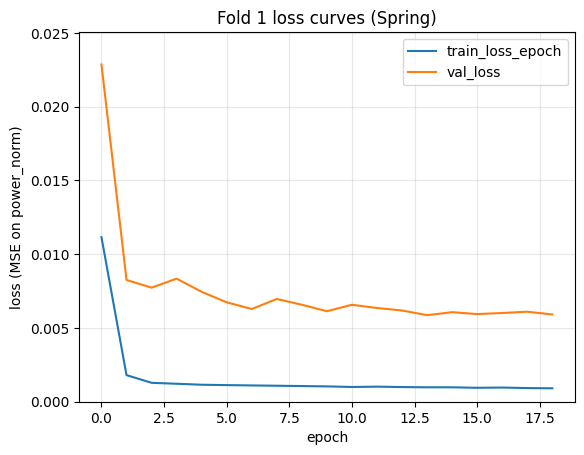

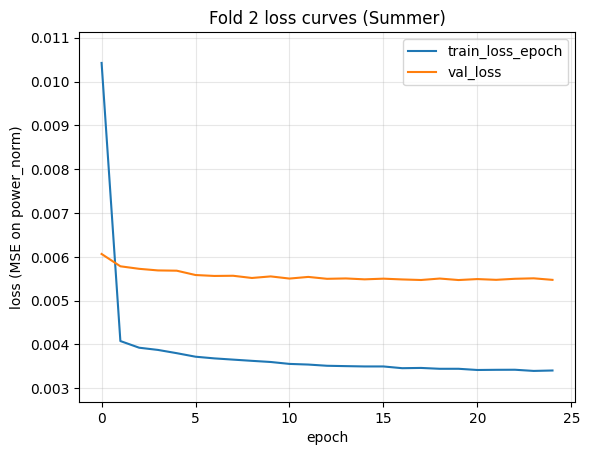

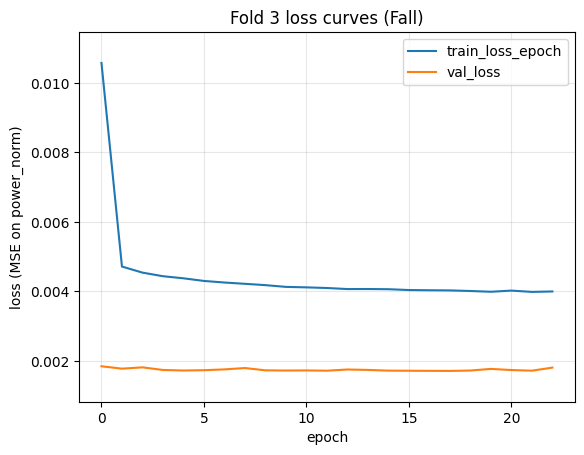

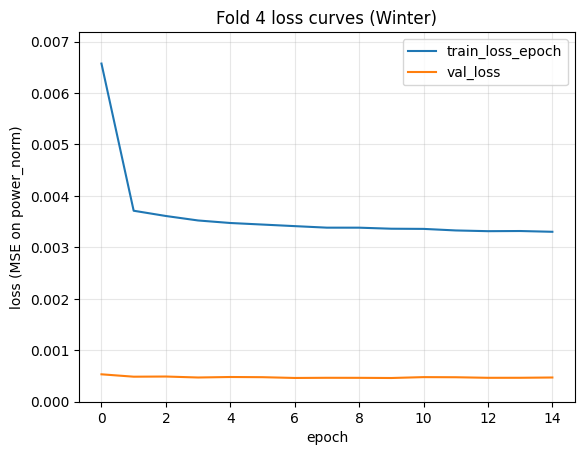

In [11]:
for k in FOLDS:
    df = read_metrics(k)
    if "epoch" not in df.columns:
        continue

    # Keep only rows where at least one of the series exists
    cols = ["epoch"]
    if "train_loss_epoch" in df.columns:
        cols.append("train_loss_epoch")
    if "val_loss" in df.columns:
        cols.append("val_loss")

    d = df[cols].copy()

    # Convert to numeric and drop NaNs per series
    d["epoch"] = pd.to_numeric(d["epoch"], errors="coerce")

    if "train_loss_epoch" in d.columns:
        d["train_loss_epoch"] = pd.to_numeric(d["train_loss_epoch"], errors="coerce")
    if "val_loss" in d.columns:
        d["val_loss"] = pd.to_numeric(d["val_loss"], errors="coerce")

    # Build figure
    plt.figure()

    plotted = False

    if "train_loss_epoch" in d.columns:
        dt = d.dropna(subset=["epoch", "train_loss_epoch"])
        if len(dt):
            plt.plot(dt["epoch"], dt["train_loss_epoch"], label="train_loss_epoch")
            plotted = True

    if "val_loss" in d.columns:
        dv = d.dropna(subset=["epoch", "val_loss"])
        if len(dv):
            plt.plot(dv["epoch"], dv["val_loss"], label="val_loss")
            plotted = True

    plt.title(f"Fold {k} loss curves ({FOLD_MAP[k]['season']})")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE on power_norm)")
    plt.legend()

    if plotted:
        # Make tiny losses visible
        yvals = []
        if "train_loss_epoch" in d.columns:
            yvals += d["train_loss_epoch"].dropna().tolist()
        if "val_loss" in d.columns:
            yvals += d["val_loss"].dropna().tolist()

        ymin = min(yvals)
        ymax = max(yvals)

        # If values are very small, log scale is best
        if ymax > 0 and ymax / max(ymin, 1e-12) > 50:
            plt.yscale("log")
        else:
            # Add a little padding
            pad = 0.1 * (ymax - ymin) if ymax > ymin else ymax * 0.1
            plt.ylim(max(0, ymin - pad), ymax + pad)

        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        plt.close()
        print(f"[WARN] Fold {k}: nothing to plot (all NaN for train_loss_epoch/val_loss)")


## 6. Practical sanity checks

Why:
- Nighttime PV is near 0, metrics can look unrealistically good.
- We compute baseline RMSE on the raw validation rows:
  1) Persistence baseline: predict y_t = y_{t-1} per plant
  2) Daytime-only RMSE using poa_irradiance threshold

Note:
- This baseline is on the raw timeseries rows, not the windowed samples.
- It is a reality check, not the exact same objective as the LSTM (next-step given window).


In [12]:
DAY_THR = 10.0  # W/m^2 threshold for "daytime", adjust if needed

def persistence_rmse(df: pd.DataFrame, day_only: bool) -> float:
    d = df.sort_values([PLANT_ID_COL, TIME_COL]).copy()
    if "poa_irradiance" in d.columns and day_only:
        d = d[d["poa_irradiance"] > DAY_THR]

    # per-plant persistence: yhat(t) = y(t-1)
    d["yhat"] = d.groupby(PLANT_ID_COL)[TARGET_COL].shift(1)
    d = d.dropna(subset=["yhat", TARGET_COL])
    err = (d["yhat"].to_numpy() - d[TARGET_COL].to_numpy())
    return float(np.sqrt(np.mean(err**2))) if len(err) else np.nan

baseline_rows = []
for k in FOLDS:
    _, va = load_fold(k)
    baseline_rows.append({
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "persistence_rmse_all": persistence_rmse(va, day_only=False),
        "persistence_rmse_day": persistence_rmse(va, day_only=True),
        "val_rows": len(va),
        "day_rows": int(((va["poa_irradiance"] > DAY_THR).sum()) if "poa_irradiance" in va.columns else 0),
    })

baseline = pd.DataFrame(baseline_rows)
baseline


,fold,season,persistence_rmse_all,persistence_rmse_day,val_rows,day_rows
0,1,Spring,0.076656,0.159993,35328,1968
1,2,Summer,0.081813,NaN,35326,0
2,3,Fall,0.045174,NaN,43674,0
3,4,Winter,0.023006,NaN,37720,0


## 7. Optional: Verify model RMSE by direct inference on windowed validation

This checks that:
- the loss numbers in metrics.csv correspond to what we compute ourselves
- the dataloader and model are aligned

This runs inference on the full val dataset for each fold.
If it is slow, reduce `MAX_BATCHES`.


In [13]:
from src.training.train_global_lstm_v3 import GroupedWindowDataset
from src.models.global_lstm_encoder import GlobalLSTMEncoder, LSTMEncoderConfig

MAX_BATCHES = None  # set e.g. 50 for a quick test

def load_model_for_fold(k: int) -> GlobalLSTMEncoder:
    # Use the same config as training defaults unless you changed them
    cfg = LSTMEncoderConfig(
        input_size=len(GLOBAL_LSTM_INPUT_FEATURES),
        hidden_size=64,
        num_layers=2,
        dropout=0.1,
        lr=1e-4,
    )
    model = GlobalLSTMEncoder(cfg)
    state = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

@torch.no_grad()
def eval_fold_windowed_rmse(k: int, batch_size: int = 512, num_workers: int = 2) -> dict:
    _, va = load_fold(k)
    ds = GroupedWindowDataset(va, window_size=96, stride=1)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    model = load_model_for_fold(k)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    se = 0.0
    n = 0
    for bi, (x, y) in enumerate(dl):
        if MAX_BATCHES is not None and bi >= MAX_BATCHES:
            break
        x = x.to(device)
        y = y.to(device)
        yhat = model(x).squeeze(-1)
        se += float(torch.sum((yhat - y) ** 2).item())
        n += int(y.numel())

    rmse = math.sqrt(se / n) if n else np.nan
    return {"fold": k, "windowed_val_rmse": rmse, "n_samples": n}

win_eval = pd.DataFrame([eval_fold_windowed_rmse(k) for k in FOLDS])
win_eval


[INFO] GroupedWindowDataset created
  window_size: 96, stride: 1
  total windows: 34,944
  windows per plant:
    plant_01: 8,736
    plant_02: 8,736
    plant_03: 8,736
    plant_06: 8,736
[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_442232/3802607308.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_loc

AttributeError: 'dict' object has no attribute 'squeeze'

## 8. Transfer learning evidence

We check:
- Similarity between Farm2107 first-layer input weights (15 features) and trained model columns 0-14
- Plant one-hot columns (15-19) should be learned, not remain all zeros after training
- Summaries: mean abs weight, std, and cosine similarity


In [ ]:
def load_state_any(ckpt_path: Path) -> dict:
    obj = torch.load(ckpt_path, map_location="cpu")
    # handle either plain state_dict or dict wrapper
    if isinstance(obj, dict) and "state_dict" in obj:
        return obj["state_dict"]
    if isinstance(obj, dict):
        return obj
    raise ValueError("Unknown checkpoint format")

farm_state = load_state_any(FARM2107_CKPT)

def find_weight_key(d: dict, contains: str) -> str:
    keys = [k for k in d.keys() if contains in k]
    if len(keys) == 1:
        return keys[0]
    if len(keys) == 0:
        raise KeyError(f"No key contains '{contains}'")
    # if multiple, pick the shortest, usually the direct param
    return sorted(keys, key=len)[0]

farm_w_ih_key = find_weight_key(farm_state, "lstm.weight_ih_l0")
farm_w_ih = farm_state[farm_w_ih_key]  # shape [4h, in]
print("Farm weight_ih_l0 shape:", tuple(farm_w_ih.shape))

rows = []
for k in FOLDS:
    glob_state = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_location="cpu")
    glob_w_ih_key = find_weight_key(glob_state, "lstm.weight_ih_l0")
    glob_w_ih = glob_state[glob_w_ih_key]
    print(f"Fold {k} global weight_ih_l0 shape:", tuple(glob_w_ih.shape))

    # Columns 0-14 are farm features. Columns 15-19 are plant one-hot.
    w_copy = glob_w_ih[:, :15].flatten()
    w_farm = farm_w_ih.flatten()

    cos = torch.nn.functional.cosine_similarity(w_copy, w_farm, dim=0).item()

    plant_cols = glob_w_ih[:, 15:20]
    rows.append({
        "fold": k,
        "cosine_similarity_farm_vs_global_cols0_14": float(cos),
        "plant_weight_mean_abs": float(plant_cols.abs().mean().item()),
        "plant_weight_std": float(plant_cols.std().item()),
        "plant_weight_max_abs": float(plant_cols.abs().max().item()),
    })

transfer_diag = pd.DataFrame(rows)
transfer_diag


Farm weight_ih_l0 shape: (256, 15)
Fold 1 global weight_ih_l0 shape: (256, 20)
Fold 2 global weight_ih_l0 shape: (256, 20)
Fold 3 global weight_ih_l0 shape: (256, 20)
Fold 4 global weight_ih_l0 shape: (256, 20)


/tmp/ipykernel_387543/1846848174.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location="cpu")
/tmp/ipykernel_387543/1846848174.py:27: 

,fold,cosine_similarity_farm_vs_global_cols0_14,plant_weight_mean_abs,plant_weight_std,plant_weight_max_abs
0,1,0.995169,0.009757,0.013443,0.050982
1,2,0.985436,0.019768,0.028067,0.121522
2,3,0.981029,0.040393,0.058173,0.261440
3,4,0.984153,0.038147,0.054469,0.260926


## 9. V2 vs V3 comparison (with caveats)

Important:
- V2 used stratified seasonal splits per plant (not a true forecasting evaluation).
- V3 uses rolling-origin time splits (more honest).
- Do not claim V2 "wins" because it has lower val RMSE. It is a different evaluation problem.

We still show a comparison table to document what changed and why.


In [ ]:
# Your V2 summary pasted earlier (per-plant)
v2 = pd.DataFrame([
    {"plant": "plant_01", "train_rmse": 0.050700, "val_rmse": 0.118000, "ratio": 2.328000},
    {"plant": "plant_02", "train_rmse": 0.067300, "val_rmse": 0.134700, "ratio": 2.002000},
    {"plant": "plant_03", "train_rmse": 0.065800, "val_rmse": 0.153600, "ratio": 2.334000},
    {"plant": "plant_05", "train_rmse": 0.038000, "val_rmse": 0.093100, "ratio": 2.451000},
    {"plant": "plant_06", "train_rmse": 0.068500, "val_rmse": 0.148900, "ratio": 2.173000},
])
v2_mean = pd.DataFrame([{
    "version": "V2 (stratified per-plant)",
    "mean_train_rmse": float(v2["train_rmse"].mean()),
    "mean_val_rmse": float(v2["val_rmse"].mean()),
    "mean_ratio": float(v2["ratio"].mean()),
}])

v3_mean = pd.DataFrame([{
    "version": "V3 (rolling-origin CV folds 1-4)",
    "mean_train_rmse": float(summ["train_rmse"].mean()),
    "mean_val_rmse": float(summ["val_rmse"].mean()),
    "mean_ratio": float(summ["train_val_ratio"].mean()),
}])

pd.concat([v2_mean, v3_mean], ignore_index=True)


,version,mean_train_rmse,mean_val_rmse,mean_ratio
0,V2 (stratified per-plant),0.058060,0.129660,2.257600
1,V3 (rolling-origin CV folds 1-4),0.052848,0.053347,1.359178


## 10. Export report tables (CSV) for your thesis appendix

Exports:
- fold data audit
- fold metric summary
- baseline sanity checks
- transfer diagnostics


In [ ]:
OUT_DIR = RUNS_DIR / "reports"
OUT_DIR.mkdir(parents=True, exist_ok=True)

audit.to_csv(OUT_DIR / "fold_data_audit.csv", index=False)
summ.to_csv(OUT_DIR / "fold_metrics_summary.csv", index=False)
baseline.to_csv(OUT_DIR / "baseline_sanity.csv", index=False)
transfer_diag.to_csv(OUT_DIR / "transfer_diagnostics.csv", index=False)

print("Saved reports to:", OUT_DIR)


Saved reports to: /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/reports


# Re checking evalutation
## Not sure if the eval metrics are correct → so checking if its an issue with the model or eval metrics

## Step 1, prove whether it’s an evaluation bug or a data bug

In [15]:
k = 1
val_path = DATA_DIR / f"fold_{k}_val.parquet"
df = pd.read_parquet(val_path)

col = "global_tilted_irradiance_instant"
print("rows:", len(df))
print("power_norm min/max:", df["power_norm"].min(), df["power_norm"].max())
print(col, "exists:", col in df.columns)

if col in df.columns:
    s = df[col]
    print(col, "min/max:", s.min(), s.max())
    print("quantiles:", s.quantile([0,0.25,0.5,0.75,0.9,0.99,1.0]).to_dict())


rows: 35328
power_norm min/max: 0.0 1.0
global_tilted_irradiance_instant exists: True
global_tilted_irradiance_instant min/max: -0.5700547348254867 14.578052832293913
quantiles: {0.0: -0.5700547348254867, 0.25: -0.5700547348254867, 0.5: 0.15713421092547114, 0.75: 4.542732647138761, 0.9: 8.275248519272749, 0.99: 12.638470797652888, 1.0: 14.578052832293913}


## Step 2, compute “day/active” rows with two masks

In [16]:
thr_p = 0.02
active = (df["power_norm"] > thr_p)

print("active rows:", active.sum(), "(", active.mean()*100, "% )")

if "global_tilted_irradiance_instant" in df.columns:
    thr_gti = 10.0
    day_gti = df["global_tilted_irradiance_instant"] > thr_gti
    print("day rows (GTI):", day_gti.sum(), "(", day_gti.mean()*100, "% )")


active rows: 16901 ( 47.84024003623188 % )
day rows (GTI): 1968 ( 5.570652173913043 % )


In [14]:
k = 1
df = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")

print("rows:", len(df))
print("power_norm min/max:", df["power_norm"].min(), df["power_norm"].max())

col = "global_tilted_irradiance_instant"
print(col, "exists:", col in df.columns)
if col in df.columns:
    s = df[col]
    print(col, "min/max:", s.min(), s.max())
    print("GTI > 10 rows:", (s > 10).sum())

print("power_norm > 0.02 rows:", (df["power_norm"] > 0.02).sum())


rows: 35328
power_norm min/max: 0.0 1.0
global_tilted_irradiance_instant exists: True
global_tilted_irradiance_instant min/max: -0.5700547348254867 14.578052832293913
GTI > 10 rows: 1968
power_norm > 0.02 rows: 16901


## Reviewer comment: CGPT 5.2
GTI max is 14.58 and even has negatives.

If this were W/m² it should peak around hundreds to ~1000+.

So your global_tilted_irradiance_instant is almost certainly normalized / scaled / in kW/m² / or some transformed unit.

That’s not fatal, but it means any “daytime” rule based on physical thresholds like > 10 W/m² is nonsense unless you know the units.

What we can safely conclude from your numbers

Daylight exists: GTI > 10 rows = 1968 (so your earlier day mask was wrong, not the data).

PV activity exists: power_norm > 0.02 rows = 16901 (almost half the rows).

Your all-row RMSE is still contaminated by night zeros, so you must report subset metrics.

# Debugging why day_rows = 0 and negative GTI values

## Step 0, set one fold and load val once

In [17]:
k = 1
val_path = DATA_DIR / f"fold_{k}_val.parquet"
df = pd.read_parquet(val_path)

print("val_path:", val_path)
print("rows:", len(df))
print("cols:", df.shape[1])
print("time min/max:", df[TIME_COL].min(), "->", df[TIME_COL].max())


val_path: /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_val.parquet
rows: 35328
cols: 22
time min/max: 2023-03-01 00:00:00+00:00 -> 2023-05-31 23:45:00+00:00


## Step 1, sanity check the two masks we trust
Note: this should have the same values as the cell above, else we are checking wrong metrics again

In [18]:
gti_col = "global_tilted_irradiance_instant"

print("GTI exists:", gti_col in df.columns)

gti = df[gti_col]
p = df["power_norm"]

print("GTI min/max:", gti.min(), gti.max())
print("GTI > 10 rows:", (gti > 10).sum())
print("power_norm > 0.02 rows:", (p > 0.02).sum())


GTI exists: True
GTI min/max: -0.5700547348254867 14.578052832293913
GTI > 10 rows: 1968
power_norm > 0.02 rows: 16901


### Note: is it correct 

## Step 2, reproduce your notebook’s broken day_rows result in isolation

In [ ]:
def compute_day_mask_broken(d: pd.DataFrame) -> pd.Series:
    # ---- paste your exact mask logic here ----
    "day_rows": int(((va["poa_irradiance"] > DAY_THR).sum()) if "poa_irradiance" in va.columns else 0), 
    # example placeholder:
    # return (d["global_tilted_irradiance_instant"] > 10) & (d["power_norm"] > 0)
    raise NotImplementedError


SyntaxError: illegal target for annotation (4014420985.py, line 2)

## Step 1: implement a proper day mask function

In [20]:
def day_mask(d: pd.DataFrame, day_thr: float = 10.0, mode: str = "gti") -> pd.Series:
    """
    Return a boolean mask for "daytime" rows.

    Parameters
    ----------
    d : pd.DataFrame
        Must contain at least timestamp_utc and either:
        - global_tilted_irradiance_instant (recommended), or
        - poa_irradiance (legacy)
    day_thr : float
        Threshold applied to the selected irradiance column.
        WARNING: only meaningful if column is in physical units.
    mode : str
        'gti' uses global_tilted_irradiance_instant if present, else falls back.
        'poa' uses poa_irradiance only.

    Returns
    -------
    pd.Series[bool]
        True for rows considered daytime.
    """
    if mode == "poa":
        col = "poa_irradiance"
        if col not in d.columns:
            raise KeyError(f"Requested mode='poa' but column '{col}' not found.")
    else:
        # default mode='gti'
        if "global_tilted_irradiance_instant" in d.columns:
            col = "global_tilted_irradiance_instant"
        elif "poa_irradiance" in d.columns:
            col = "poa_irradiance"
        else:
            raise KeyError("No irradiance column found. Expected 'global_tilted_irradiance_instant' or 'poa_irradiance'.")

    s = pd.to_numeric(d[col], errors="coerce")
    m = s > float(day_thr)

    # Hard guard: if it returns 0, tell you immediately
    if int(m.sum()) == 0:
        print(f"[WARN] day_mask produced 0 rows using col='{col}' with day_thr={day_thr}.")
        print(f"       {col} min/max:", float(s.min()), float(s.max()))
    return m


## Step 2: replace your baseline sanity day_rows computation

In [32]:
DAY_THR = 10.0  # keep same threshold for now

dm = day_mask(va, day_thr=DAY_THR, mode="gti")
day_rows = int(dm.sum())


[WARN] day_mask produced 0 rows using col='global_tilted_irradiance_instant' with day_thr=10.0.
       global_tilted_irradiance_instant min/max: -0.671514157251241 1.06078921798217


In [29]:
k = 1
va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")

dm = day_mask(va, day_thr=10.0, mode="gti")
print("day_rows:", int(dm.sum()))
print("active_rows:", int((va["power_norm"] > 0.02).sum()))


day_rows: 1968
active_rows: 16901


In [30]:
for k in FOLDS:
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")
    s = va["global_tilted_irradiance_instant"]
    print(k, "min/max:", float(s.min()), float(s.max()), "mean/std:", float(s.mean()), float(s.std()))


1 min/max: -0.5700547348254867 14.578052832293913 mean/std: 2.296364452581868 3.717962184206825
2 min/max: -0.620538104978984 4.28801909096108 mean/std: 0.662583842206086 1.400754833727138
3 min/max: -0.7295557065427001 1.982850816113528 mean/std: -0.39156536876568265 0.5662930200589064
4 min/max: -0.671514157251241 1.06078921798217 mean/std: -0.5392060355314726 0.252050233088433


# ISSUE FOUND → THE GTI coulmns in folds 1-4 are zscore scaled and normalized

## 1) Confirm the fold data is normalized (and which columns)

NOTE: If GTI is listed there, it’s normalized. That’s the smoking gun.

In [33]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT = Path.home() / "pv_forecast_30d"
DATA_DIR = REPO_ROOT / "data" / "processed" / "pretraining" / "germany" / "global"

k = 2  # pick the fold that shows the warning
scaler_path = DATA_DIR / f"fold_{k}_scaler.json"
scaler = json.loads(scaler_path.read_text())

print("normalized_columns:", scaler["normalized_columns"][:5], "... total =", len(scaler["normalized_columns"]))
print("has global_tilted_irradiance_instant:", "global_tilted_irradiance_instant" in scaler["normalized_columns"])
print("has poa_irradiance:", "poa_irradiance" in scaler["normalized_columns"])


normalized_columns: ['poa_irradiance', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'weather_code'] ... total = 14
has global_tilted_irradiance_instant: True
has poa_irradiance: True


## 2) Load val fold, show the “wrong” GTI range (normalized)

In [34]:
import numpy as np

va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")

col = "global_tilted_irradiance_instant"
print("val rows:", len(va))
print(col, "min/max:", float(np.nanmin(va[col])), float(np.nanmax(va[col])))
print("rows > 10:", int((va[col] > 10).sum()))


val rows: 35326
global_tilted_irradiance_instant min/max: -0.620538104978984 4.28801909096108
rows > 10: 0


## 3) Fix the notebook by denormalizing a copy for “physical checks”

Do not change training data. Just create a “human units” view for sanity checks.

In [35]:
def denormalize_for_audit(df: pd.DataFrame, scaler: dict) -> pd.DataFrame:
    out = df.copy()
    stats = scaler["stats"]
    for c in scaler["normalized_columns"]:
        mu = stats[c]["mean"]
        sd = stats[c]["std"]
        out[c] = out[c] * sd + mu
    return out

va_raw = denormalize_for_audit(va, scaler)

col = "global_tilted_irradiance_instant"
print(col, "RAW min/max:", float(np.nanmin(va_raw[col])), float(np.nanmax(va_raw[col])))
print("RAW rows > 10:", int((va_raw[col] > 10).sum()))


global_tilted_irradiance_instant RAW min/max: 0.0 739.93054
RAW rows > 10: 22212


## 4) Replace your day_mask to always operate on the audit view

In [36]:
def day_mask_from_raw_gti(df_raw: pd.DataFrame, thr: float = 10.0) -> pd.Series:
    c = "global_tilted_irradiance_instant"
    x = df_raw[c].clip(lower=0)  # avoid tiny negatives from interpolation/sensor noise
    return x > thr

dm = day_mask_from_raw_gti(va_raw, thr=10.0)
print("day rows:", int(dm.sum()))


day rows: 22212


### If you want this to be unit-robust (because your irradiance units might not be W/m²), use an adaptive threshold:

In [39]:
def day_mask_adaptive(df_raw: pd.DataFrame) -> pd.Series:
    c = "global_tilted_irradiance_instant"
    x = df_raw[c].clip(lower=0)
    thr = np.nanpercentile(x, 99) * 0.02  # 2% of “near-max”
    return x > thr

dm = day_mask_adaptive(va_raw)
print("adaptive day rows:", int(dm.sum()))


adaptive day rows: 21866


# 5) Fix the “empty plots” reliably (metrics path + numeric coercion)

In [40]:
import glob
import pandas as pd
from pathlib import Path

RUNS_DIR = REPO_ROOT / "experiments" / "lstm" / "runs" / "germany" / "global_v3"

def find_metrics_csv(fold: int) -> Path:
    candidates = sorted(glob.glob(str(RUNS_DIR / f"fold_{fold}" / "**" / "metrics.csv"), recursive=True))
    if not candidates:
        raise FileNotFoundError(f"No metrics.csv found for fold {fold}")
    return Path(candidates[-1])  # take latest

def read_metrics(fold: int) -> pd.DataFrame:
    p = find_metrics_csv(fold)
    df = pd.read_csv(p)
    for c in ["epoch", "train_loss_epoch", "val_loss"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

df = read_metrics(k)
print(find_metrics_csv(k))
print(df[["epoch","train_loss_epoch","val_loss"]].tail(10))


/home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_2/logs/metrics.csv
     epoch  train_loss_epoch  val_loss
153     23               NaN       NaN
154     23               NaN  0.005509
155     23          0.003396       NaN
156     24               NaN       NaN
157     24               NaN       NaN
158     24               NaN       NaN
159     24               NaN       NaN
160     24               NaN       NaN
161     24               NaN  0.005474
162     24          0.003406       NaN


### Plot only non NaN rows

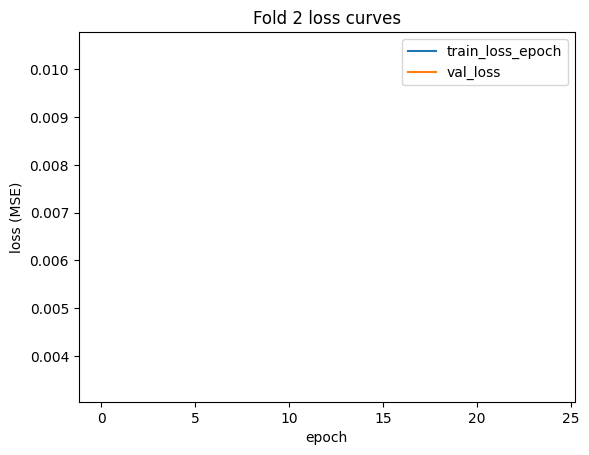

In [41]:
import matplotlib.pyplot as plt

def plot_losses(fold: int):
    df = read_metrics(fold)
    if "epoch" not in df.columns:
        print("No epoch column.")
        return
    x = df["epoch"].to_numpy()

    plt.figure()
    if "train_loss_epoch" in df.columns and df["train_loss_epoch"].notna().any():
        plt.plot(x, df["train_loss_epoch"].to_numpy(), label="train_loss_epoch")
    if "val_loss" in df.columns and df["val_loss"].notna().any():
        plt.plot(x, df["val_loss"].to_numpy(), label="val_loss")
    plt.title(f"Fold {fold} loss curves")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE)")
    plt.legend()
    plt.show()

plot_losses(k)


# FIX: Make day_mask operate in the right space

In [45]:
import json
from pathlib import Path

def load_fold_scaler(k: int) -> dict:
    """
    Load fold scaler stats robustly across older/newer JSON formats.

    Supports:
      A) {"stats": {col: {"mean":..., "std":...}}, "normalized_columns":[...]}
      B) {col: {"mean":..., "std":...}}  (older)
    """
    p = DATA_DIR / f"fold_{k}_scaler.json"
    if not p.exists():
        raise FileNotFoundError(f"Missing fold scaler: {p}")

    obj = json.loads(p.read_text())

    # Newer format
    if isinstance(obj, dict) and "stats" in obj and isinstance(obj["stats"], dict):
        stats = obj["stats"]
        norm_cols = obj.get("normalized_columns", list(stats.keys()))
        return {"stats": stats, "normalized_columns": norm_cols, "_path": str(p)}

    # Older format
    if isinstance(obj, dict) and len(obj) and all(isinstance(v, dict) for v in obj.values()):
        stats = obj
        norm_cols = list(stats.keys())
        return {"stats": stats, "normalized_columns": norm_cols, "_path": str(p)}

    raise ValueError(f"Unrecognized scaler JSON structure in {p}")


In [46]:
import numpy as np
import pandas as pd

def inverse_zscore(x: pd.Series, mu: float, sd: float) -> pd.Series:
    """
    Invert z-score normalization: raw = z * std + mean
    """
    if sd == 0 or not np.isfinite(sd):
        raise ValueError(f"Bad std for inverse_zscore: std={sd}")
    return x.astype(float) * float(sd) + float(mu)

def day_mask_from_fold(df_fold: pd.DataFrame, k: int, raw_day_thr: float = 10.0) -> pd.Series:
    """
    Day-mask for fold data where irradiance columns are z-scored.

    Steps:
      1) Load fold scaler (trained on fold train set).
      2) Inverse-transform GTI to raw units.
      3) Apply raw threshold.
    """
    scaler = load_fold_scaler(k)
    stats = scaler["stats"]

    col = "global_tilted_irradiance_instant"
    if col not in df_fold.columns:
        raise KeyError(f"Fold df missing column '{col}'. Columns: {list(df_fold.columns)[:10]} ...")

    if col not in stats:
        # Hard fail, because otherwise you will silently compute nonsense day masks.
        raise KeyError(
            f"Scaler stats missing '{col}'. Available stats keys: {list(stats.keys())[:15]} ..."
        )

    mu = float(stats[col]["mean"])
    sd = float(stats[col]["std"])

    gti_raw = inverse_zscore(df_fold[col], mu, sd)
    dm = gti_raw > float(raw_day_thr)

    # Debug print (keep it, it saves hours)
    print(f"[day_mask] fold={k} scaler={scaler['_path']}")
    print(f"[day_mask] GTI z min/max: {df_fold[col].min():.4f} / {df_fold[col].max():.4f}")
    print(f"[day_mask] GTI raw min/max: {gti_raw.min():.4f} / {gti_raw.max():.4f}")
    print(f"[day_mask] day_rows: {int(dm.sum())} / {len(dm)}")

    return dm


In [47]:
k = 4
va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")
dm = day_mask_from_fold(va, k, raw_day_thr=10.0)
print("day rows:", int(dm.sum()), "of", len(va))


[day_mask] fold=4 scaler=/home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_scaler.json
[day_mask] GTI z min/max: -0.6715 / 1.0608
[day_mask] GTI raw min/max: 0.0000 / 289.0531
[day_mask] day_rows: 11744 / 37720
day rows: 11744 of 37720


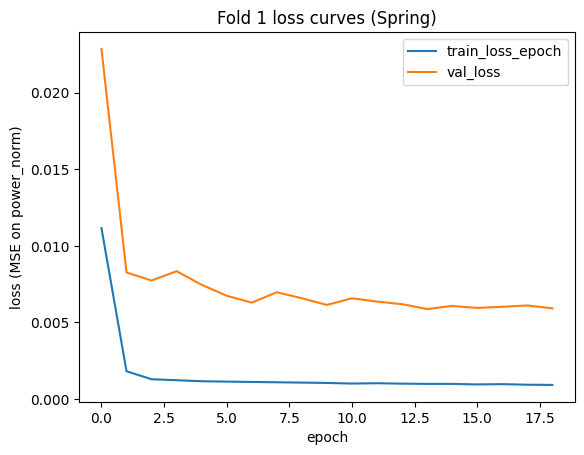

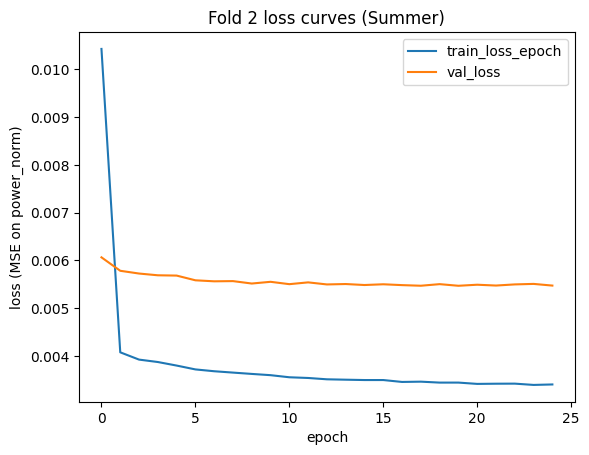

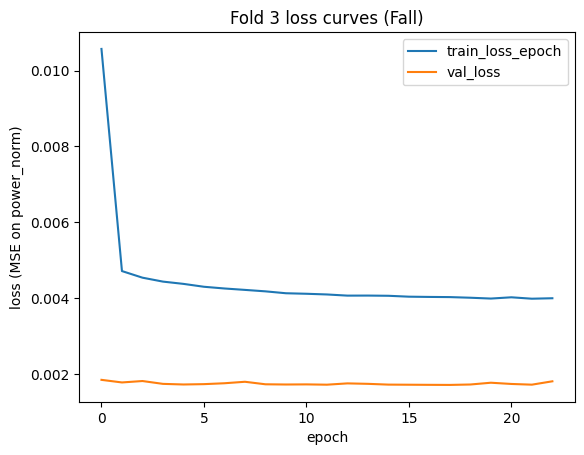

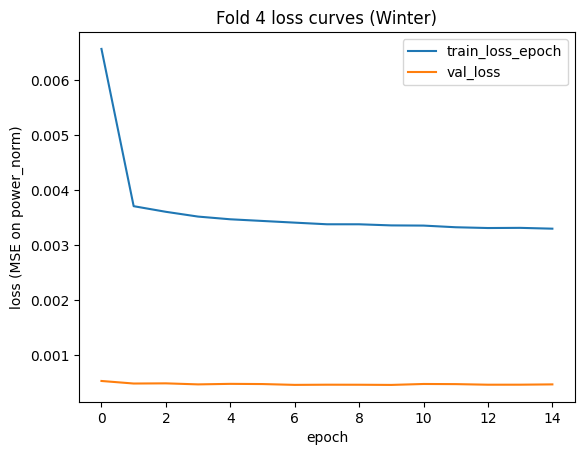

In [48]:
def read_metrics(k: int) -> pd.DataFrame:
    """
    Read Lightning CSV logs. Your runs write to: fold_k/logs/metrics.csv
    """
    p = RUNS_DIR / f"fold_{k}" / "logs" / "metrics.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing metrics.csv: {p}")
    df = pd.read_csv(p)
    if "epoch" not in df.columns and "step" in df.columns:
        df["epoch"] = df["step"]
    return df

for k in FOLDS:
    df = read_metrics(k)

    fig = plt.figure()
    if "epoch" in df.columns and "train_loss_epoch" in df.columns:
        dtr = df.dropna(subset=["epoch", "train_loss_epoch"])
        if len(dtr):
            plt.plot(dtr["epoch"].to_numpy(), dtr["train_loss_epoch"].to_numpy(), label="train_loss_epoch")

    if "epoch" in df.columns and "val_loss" in df.columns:
        dva = df.dropna(subset=["epoch", "val_loss"])
        if len(dva):
            plt.plot(dva["epoch"].to_numpy(), dva["val_loss"].to_numpy(), label="val_loss")

    plt.title(f"Fold {k} loss curves ({FOLD_MAP[k]['season']})")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE on power_norm)")
    plt.legend()
    plt.show()


# Cell A, helpers: load model and build predictions

This assumes your model predicts next-step power_norm from windows, same as training.

In [59]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import math

# Import your model + config
from src.models.global_lstm_encoder import GlobalLSTMEncoder, LSTMEncoderConfig
from src.data.schema import GLOBAL_LSTM_INPUT_FEATURES, TARGET_COL, PLANT_ID_COL, TIME_COL, TIME_STEP_MINUTES

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_fold_model(k: int, hidden_size=64, num_layers=2, dropout=0.1, lr=1e-4) -> GlobalLSTMEncoder:
    """
    Load the trained fold-k model saved at:
      RUNS_DIR/fold_k/lstm_encoder_global_fold_k.pt
    """
    cfg = LSTMEncoderConfig(
        input_size=len(GLOBAL_LSTM_INPUT_FEATURES),
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        lr=lr,
    )
    m = GlobalLSTMEncoder(cfg).to(DEVICE)
    wpath = RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt"
    if not wpath.exists():
        raise FileNotFoundError(f"Missing model weights: {wpath}")
    state = torch.load(wpath, map_location=DEVICE)
    m.load_state_dict(state)
    m.eval()
    return m

@torch.no_grad()
def predict_on_loader(model: torch.nn.Module, loader: DataLoader) -> np.ndarray:
    """
    Collect model predictions for all batches in loader.
    Returns 1D numpy array of predictions aligned to dataset order.
    """
    preds = []
    for X, _y in loader:
        X = X.to(DEVICE)
        yhat = model(X)
        # yhat shape can be (B,) or (B,1)
        yhat = yhat.detach().cpu().numpy().reshape(-1)
        preds.append(yhat)
    return np.concatenate(preds, axis=0)


# Cell B, build evaluation windows aligned with timestamps and plant_id

Your GroupedWindowDataset returns (X,y) only, so we need an evaluation dataset that also returns metadata (timestamp and plant_id for the target time).

In [60]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import torch

class GroupedWindowDatasetWithMeta(Dataset):
    """
    Same windowing as training, but returns (X, y, plant_id, t_target).

    - X: window_size timesteps ending at t-1
    - y: target at t
    - meta: plant_id and timestamp at t (target time)
    """
    def __init__(self, df: pd.DataFrame, window_size: int = 96, stride: int = 1):
        self.window_size = int(window_size)
        self.stride = int(stride)

        d = df.copy()
        d[TIME_COL] = pd.to_datetime(d[TIME_COL], utc=True)
        d = d.sort_values([PLANT_ID_COL, TIME_COL]).reset_index(drop=True)

        # enforce no NaNs (same as training)
        X_all = d[GLOBAL_LSTM_INPUT_FEATURES].to_numpy()
        y_all = d[TARGET_COL].to_numpy()
        if np.isnan(X_all).any() or np.isnan(y_all).any():
            raise ValueError("Dataset contains NaNs. Fix preprocessing first.")

        self._by_plant = {}
        self._index = []  # (plant_id, start_idx)
        freq_s = int(TIME_STEP_MINUTES * 60)

        for plant_id, g in d.groupby(PLANT_ID_COL, sort=True):
            g = g.sort_values(TIME_COL).reset_index(drop=True)
            times = g[TIME_COL].astype("int64").to_numpy() // 10**9
            X = g[GLOBAL_LSTM_INPUT_FEATURES].to_numpy(dtype=np.float32)
            y = g[TARGET_COL].to_numpy(dtype=np.float32)
            t = g[TIME_COL].to_numpy(dtype="datetime64[ns]")  # collate-safe base dtype

            n = len(g)
            if n <= self.window_size:
                continue

            diffs = np.diff(times)
            good_step = (diffs == freq_s)

            max_start = n - self.window_size - 1
            for i in range(0, max_start + 1, self.stride):
                if good_step[i : i + self.window_size].all():
                    self._index.append((plant_id, i))

            self._by_plant[plant_id] = {"X": X, "y": y, "t": t}

        if len(self._index) == 0:
            raise ValueError("No valid windows created. Check regularity + window_size.")

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        plant_id, i = self._index[idx]
        X = self._by_plant[plant_id]["X"][i : i + self.window_size]
        y = self._by_plant[plant_id]["y"][i + self.window_size]
        t_target = self._by_plant[plant_id]["t"][i + self.window_size]
        t_target = self._by_plant[plant_id]["t"][i + self.window_size]

        # Convert datetime64[ns] -> int64 nanoseconds since epoch (DataLoader can collate this)
        t_target_ns = np.int64(t_target.astype("datetime64[ns]").astype(np.int64))

        return torch.from_numpy(X), torch.tensor(y, dtype=torch.float32), plant_id, t_target_ns


def make_val_loader_with_meta(df_val: pd.DataFrame, window_size=96, batch_size=256, num_workers=2) -> DataLoader:
    ds = GroupedWindowDatasetWithMeta(df_val, window_size=window_size, stride=1)
    # shuffle=False to preserve dataset order so preds align with metas
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)


# Cell C, compute day mask on val fold in raw units (uses your fixed functions)

This uses your day_mask_from_fold() (inverse-transform GTI).

In [61]:
def compute_day_mask_series(va: pd.DataFrame, k: int, raw_day_thr: float = 10.0) -> pd.Series:
    """
    Day mask on *rows* of va (not windows).
    Uses inverse transform from fold scaler.
    """
    dm = day_mask_from_fold(va, k, raw_day_thr=raw_day_thr)
    # Ensure it's aligned to va index
    dm = pd.Series(dm.to_numpy(), index=va.index)
    return dm


# Cell D, compute persistence RMSE and model RMSE on DAY rows

Important: your model predicts y[t] from window up to t-1.
Persistence baseline here should be y_hat[t] = y[t-1].

We need to align each window’s target time with y[t-1]. We can do that using the metadata timestamp and plant group in the val dataframe.

In [62]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def evaluate_fold_day_metrics(
    k: int,
    window_size: int = 96,
    batch_size: int = 256,
    num_workers: int = 2,
    raw_day_thr: float = 10.0,
) -> dict:
    """
    Compute:
      - model RMSE on day rows (based on target timestamps)
      - persistence RMSE on day rows
      - per-plant breakdown
    """
    # Load fold data
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet").copy()
    va[TIME_COL] = pd.to_datetime(va[TIME_COL], utc=True)

    # Build a lookup for persistence: y[t-1] per (plant_id, timestamp)
    # For each plant, shift target by 1 step to align with current timestamp
    va = va.sort_values([PLANT_ID_COL, TIME_COL]).reset_index(drop=True)
    va["y_true"] = va[TARGET_COL].astype(float)
    va["y_prev"] = va.groupby(PLANT_ID_COL)["y_true"].shift(1)

    # Day mask on rows
    dm_rows = compute_day_mask_series(va, k, raw_day_thr=raw_day_thr)

    # Build window loader with meta
    loader = make_val_loader_with_meta(va, window_size=window_size, batch_size=batch_size, num_workers=num_workers)

    # Load fold model and predict
    model = load_fold_model(k)
    preds = []
    ys = []
    pids = []
    tts = []

    with torch.no_grad():
        for X, y, pid, tt in loader:
            X = X.to(DEVICE)
            yhat = model(X).detach().cpu().numpy().reshape(-1)
            preds.append(yhat)
            ys.append(y.detach().cpu().numpy().reshape(-1))
            pids.extend(list(pid))
            tts.extend(list(tt))

    yhat = np.concatenate(preds)
    ytrue = np.concatenate(ys)
    meta = pd.DataFrame({
    PLANT_ID_COL: pids,
    TIME_COL: pd.to_datetime(np.array(tts, dtype="int64"), utc=True, unit="ns"),
    })

    meta["yhat"] = yhat
    meta["ytrue"] = ytrue

    # Join persistence y_prev and day mask onto window targets
    join_cols = [PLANT_ID_COL, TIME_COL]
    meta = meta.merge(
        va[join_cols + ["y_prev"]].copy(),
        on=join_cols,
        how="left",
    )
    meta = meta.merge(
        pd.DataFrame({ "row_idx": va.index, **{TIME_COL: va[TIME_COL], PLANT_ID_COL: va[PLANT_ID_COL], "is_day": dm_rows.values} })[
            [PLANT_ID_COL, TIME_COL, "is_day"]
        ],
        on=join_cols,
        how="left",
    )

    # Filter to day rows and valid persistence
    day_meta = meta[(meta["is_day"] == True) & meta["y_prev"].notna()].copy()
    if len(day_meta) == 0:
        raise RuntimeError(f"Fold {k}: 0 day windows after join. Check mask and timestamp alignment.")

    # Metrics
    model_rmse_day = rmse(day_meta["yhat"].to_numpy(), day_meta["ytrue"].to_numpy())
    persist_rmse_day = rmse(day_meta["y_prev"].to_numpy(), day_meta["ytrue"].to_numpy())

    # Per-plant
    per_plant = []
    for pid, g in day_meta.groupby(PLANT_ID_COL):
        per_plant.append({
            "fold": k,
            "plant_id": pid,
            "n_day_windows": len(g),
            "model_rmse_day": rmse(g["yhat"].to_numpy(), g["ytrue"].to_numpy()),
            "persist_rmse_day": rmse(g["y_prev"].to_numpy(), g["ytrue"].to_numpy()),
        })
    per_plant_df = pd.DataFrame(per_plant).sort_values("plant_id")

    return {
        "fold": k,
        "n_val_rows": int(len(va)),
        "n_day_rows": int(dm_rows.sum()),
        "n_day_windows": int(len(day_meta)),
        "model_rmse_day": model_rmse_day,
        "persist_rmse_day": persist_rmse_day,
        "delta_vs_persist_day": model_rmse_day - persist_rmse_day,
        "per_plant_day": per_plant_df,
        "day_meta_sample": day_meta.head(5),
    }


# Cell E, run it for all folds and summarize

In [63]:
k = 4
out = evaluate_fold_day_metrics(k, window_size=96, batch_size=256, num_workers=0, raw_day_thr=10.0)
out["n_day_windows"], out["model_rmse_day"], out["persist_rmse_day"]


[day_mask] fold=4 scaler=/home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_scaler.json
[day_mask] GTI z min/max: -0.6715 / 1.0608
[day_mask] GTI raw min/max: 0.0000 / 289.0531
[day_mask] day_rows: 11744 / 37720
[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_442232/3605818757.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(wpath, map_location=DEVICE)


AttributeError: 'dict' object has no attribute 'detach'

In [58]:
results = []
perplant_all = []

for k in FOLDS:
    out = evaluate_fold_day_metrics(k, window_size=96, batch_size=256, num_workers=2, raw_day_thr=10.0)
    results.append({
        "fold": out["fold"],
        "n_val_rows": out["n_val_rows"],
        "n_day_rows": out["n_day_rows"],
        "n_day_windows": out["n_day_windows"],
        "model_rmse_day": out["model_rmse_day"],
        "persist_rmse_day": out["persist_rmse_day"],
        "delta_vs_persist_day": out["delta_vs_persist_day"],
    })
    perplant_all.append(out["per_plant_day"])

summary_df = pd.DataFrame(results).sort_values("fold")
perplant_df = pd.concat(perplant_all, ignore_index=True)

summary_df, perplant_df


[day_mask] fold=1 scaler=/home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_scaler.json
[day_mask] GTI z min/max: -0.5701 / 14.5781
[day_mask] GTI raw min/max: 0.0000 / 719.7259
[day_mask] day_rows: 19262 / 35328
[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_442232/3605818757.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(wpath, map_location=DEVICE)


AttributeError: 'dict' object has no attribute 'detach'

In [54]:
import json
p = DATA_DIR / "fold_1_scaler.json"
obj = json.loads(p.read_text())
print("top-level keys:", list(obj.keys())[:20])


top-level keys: ['normalized_columns', 'stats']
